### Step 1 — Upload and extract the dataset

**Cell 1**: Upload the ZIP file from your computer.

In [ ]:
from google.colab import files

uploaded = files.upload()
# Run this cell and select: archive (27).zip

Saving archive (27).zip to archive (27).zip


**Cell 2**: Extract the ZIP dataset.

In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]
extract_path = "/content/student_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")
print("\nFiles found:")
for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        print(os.path.join(root, file))

Extracted successfully!

Files found:
/content/student_dataset/Students_Performance_dataset.csv


### Step 2 — Find the CSV automatically

**Cell 3**: Search recursively for `.csv` files.

In [ ]:
import glob

csv_files = glob.glob("/content/student_dataset/**/*.csv", recursive=True)

print("CSV files found:")
for f in csv_files:
    print(f)

CSV files found:
/content/student_dataset/Students_Performance_dataset.csv


### Step 3 — Load the CSV

**Cell 4**: Read the detected CSV dataset.

In [ ]:
import pandas as pd

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1194
Columns: 31


### Step 4 — See every column

**Cell 5**: Check the exact names of all columns in the dataset.

In [ ]:
print("All columns:\n")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

All columns:

1. University Admission year
2. Gender
3. Age
4. H.S.C passing year
5. Program
6. Current Semester
7. Do you have meritorious scholarship ?
8. Do you use University transportation?
9. How many hour do you study daily?
10. How many times do you seat for study in a day?
11. What is your preferable learning mode?
12. Do you use smart phone?
13. Do you have personal Computer?
14. How many hour do you spent daily in social media?
15. Status of your English language proficiency
16. Average attendance on class
17. Did you ever fall in probation?
18. Did you ever got suspension?
19. Do you attend in teacher consultancy for any kind of academical problems?
20. What are the skills do you have ?
21. How many hour do you spent daily on your skill development?
22. What is you interested area?
23. What is your relationship status?
24. Are you engaged with any co-curriculum activities?
25. With whom you are living with?
26. Do you have any health issues?
27. What was your previous SGPA?

### Step 5 — Understand the data types

**Cell 6**: Print column types and counts.

In [ ]:
df.info()

### Step 6 — Check missing values

**Cell 7**: Summary of missing data points.

In [ ]:
missing = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing.sort_values("Missing_Count", ascending=False)
display(missing)

,Column,Missing_Count,Missing_Percentage
What are the skills do you have ?,What are the skills do you have ?,1,0.08
Gender,Gender,0,0.00
University Admission year,University Admission year,0,0.00
H.S.C passing year,H.S.C passing year,0,0.00
Program,Program,0,0.00
Current Semester,Current Semester,0,0.00
Age,Age,0,0.00
Do you use University transportation?,Do you use University transportation?,0,0.00
How many hour do you study daily?,How many hour do you study daily?,0,0.00
How many times do you seat for study in a day?,How many times do you seat for study in a day?,0,0.00


### Step 7 — Check unique values in every column

**Cell 8**: Examine the cardinality of features.

In [ ]:
unique_info = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique(dropna=False) for col in df.columns]
})
unique_info = unique_info.sort_values("Unique_Values")
display(unique_info)

,Column,Unique_Values
4,Program,1
1,Gender,2
6,Do you have meritorious scholarship ?,2
7,Do you use University transportation?,2
10,What is your preferable learning mode?,2
12,Do you have personal Computer?,2
11,Do you use smart phone?,2
16,Did you ever fall in probation?,2
23,Are you engaged with any co-curriculum activit...,2
18,Do you attend in teacher consultancy for any k...,2


### Step 8 — Automatically find possible target columns

**Cell 9**: Target candidates based on academic keywords.

In [ ]:
keywords = [
    "result", "outcome", "performance", "cgpa", "sgpa",
    "probation", "suspension", "fail", "dropout", "status",
    "risk", "grade"
]

candidate_columns = []
for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in keywords):
        candidate_columns.append(col)

print("Potential outcome/target columns:\n")
for col in candidate_columns:
    print("-", col)

Potential outcome/target columns:

- Status of your English language proficiency
- Did you ever fall in probation?
- Did you ever got suspension?
- What is your relationship status?
- What was your previous SGPA?
- What is your current CGPA?


### Step 9 — Inspect the candidate columns

**Cell 10**: Value counts of potential targets.

In [ ]:
for col in candidate_columns:
    print("\n" + "="*70)
    print("COLUMN:", col)
    print("DATA TYPE:", df[col].dtype)
    print("UNIQUE VALUES:", df[col].nunique())
    print("\nVALUE COUNTS:")
    print(df[col].value_counts(dropna=False).head(20))


COLUMN: Status of your English language proficiency
DATA TYPE: object
UNIQUE VALUES: 3

VALUE COUNTS:
Status of your English language proficiency
Intermediate    670
Basic           304
Advance         220
Name: count, dtype: int64

COLUMN: Did you ever fall in probation?
DATA TYPE: object
UNIQUE VALUES: 2

VALUE COUNTS:
Did you ever fall in probation?
No     896
Yes    298
Name: count, dtype: int64

COLUMN: Did you ever got suspension?
DATA TYPE: object
UNIQUE VALUES: 2

VALUE COUNTS:
Did you ever got suspension?
No     1148
Yes      46
Name: count, dtype: int64

COLUMN: What is your relationship status?
DATA TYPE: object
UNIQUE VALUES: 5

VALUE COUNTS:
What is your relationship status?
Single               896
Relationship         186
Married               96
Engaged               15
In a relationship      1
Name: count, dtype: int64

COLUMN: What was your previous SGPA?
DATA TYPE: float64
UNIQUE VALUES: 249

VALUE COUNTS:
What was your previous SGPA?
2.68    144
0.00     39
4.00   

### Step 10 — Examine Current CGPA

**Cell 11**: Distribution statistics for the continuous target candidate.

In [ ]:
cgpa_col = "What is your current CGPA?" if "What is your current CGPA?" in df.columns else (candidate_columns[0] if candidate_columns else df.columns[0])
print(df[cgpa_col].describe())
print("\nMissing values:", df[cgpa_col].isna().sum())
print("Unique values:", df[cgpa_col].nunique())

count    1194.000000
mean        3.165603
std         0.750132
min         0.000000
25%         2.900000
50%         3.210000
75%         3.670000
max         4.000000
Name: What is your current CGPA?, dtype: float64

Missing values: 0
Unique values: 187


**Cell 12**: Visualize CGPA Distribution.

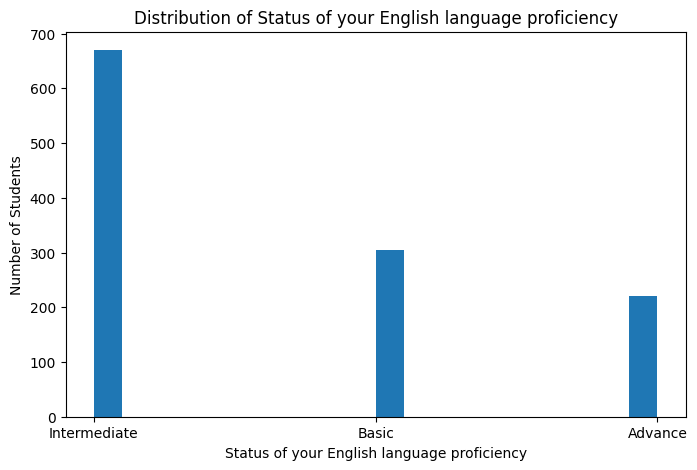

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df[cgpa_col].dropna(), bins=20)
plt.xlabel(cgpa_col)
plt.ylabel("Number of Students")
plt.title(f"Distribution of {cgpa_col}")
plt.show()

### Step 11 — Inspect probation status

**Cell 13**: Investigate categorical class balance for probation.

In [ ]:
probation_col = "Did you ever fall in probation?" if "Did you ever fall in probation?" in df.columns else "probation"
if probation_col in df.columns:
    print(df[probation_col].value_counts(dropna=False))
    print("\nPercentage:")
    print(df[probation_col].value_counts(normalize=True, dropna=False) * 100)
else:
    print(f"Column '{probation_col}' not found. Skipping.")

Did you ever fall in probation?
No     896
Yes    298
Name: count, dtype: int64

Percentage:
Did you ever fall in probation?
No     75.041876
Yes    24.958124
Name: proportion, dtype: float64


**Cell 14**: Plot probation counts.

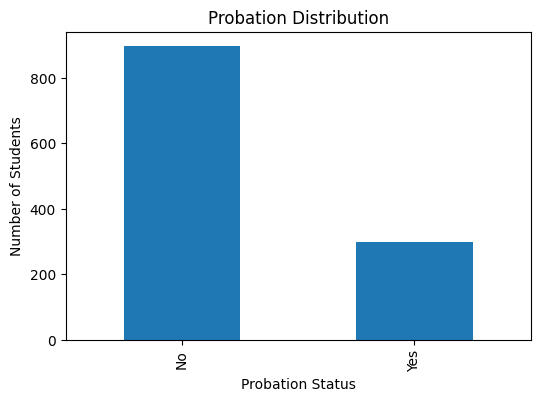

In [ ]:
if probation_col in df.columns:
    plt.figure(figsize=(6, 4))
    df[probation_col].value_counts().plot(kind="bar")
    plt.xlabel("Probation Status")
    plt.ylabel("Number of Students")
    plt.title("Probation Distribution")
    plt.show()

### Step 12 — Inspect suspension

**Cell 15**: Check class balance of the suspension variable.

In [ ]:
suspension_col = "Did you ever got suspension?" if "Did you ever got suspension?" in df.columns else "suspension"
if suspension_col in df.columns:
    print(df[suspension_col].value_counts(dropna=False))
    print("\nPercentage:")
    print(df[suspension_col].value_counts(normalize=True, dropna=False).mul(100).round(2))
else:
    print(f"Column '{suspension_col}' not found. Skipping.")

Did you ever got suspension?
No     1148
Yes      46
Name: count, dtype: int64

Percentage:
Did you ever got suspension?
No     96.15
Yes     3.85
Name: proportion, dtype: float64


### Step 13 — Check the relationship between academic variables

**Cell 16**: Numeric features correlation.

In [ ]:
numeric_cols = df.select_dtypes(include=["number"]).columns
correlation_matrix = df[numeric_cols].corr()
display(correlation_matrix.round(2))

,University Admission year,Age,H.S.C passing year,Current Semester,How many hour do you study daily?,How many times do you seat for study in a day?,How many hour do you spent daily in social media?,How many hour do you spent daily on your skill development?,What was your previous SGPA?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
University Admission year,1.00,-0.65,0.78,-0.83,-0.01,-0.01,-0.02,-0.13,-0.09,-0.11,-0.67,-0.05
Age,-0.65,1.00,-0.67,0.59,-0.01,0.02,0.02,0.12,0.02,0.07,0.48,0.03
H.S.C passing year,0.78,-0.67,1.00,-0.58,0.00,-0.00,0.02,-0.07,-0.17,-0.05,-0.39,0.03
Current Semester,-0.83,0.59,-0.58,1.00,-0.02,0.04,0.07,0.19,-0.05,0.18,0.90,0.12
How many hour do you study daily?,-0.01,-0.01,0.00,-0.02,1.00,0.37,0.02,0.14,0.04,0.02,-0.01,-0.00
How many times do you seat for study in a day?,-0.01,0.02,-0.00,0.04,0.37,1.00,-0.06,0.13,0.01,0.05,0.06,0.04
How many hour do you spent daily in social media?,-0.02,0.02,0.02,0.07,0.02,-0.06,1.00,-0.03,-0.18,-0.05,0.11,0.05
How many hour do you spent daily on your skill development?,-0.13,0.12,-0.07,0.19,0.14,0.13,-0.03,1.00,0.00,0.08,0.19,0.01
What was your previous SGPA?,-0.09,0.02,-0.17,-0.05,0.04,0.01,-0.18,0.00,1.00,0.76,-0.13,-0.12
What is your current CGPA?,-0.11,0.07,-0.05,0.18,0.02,0.05,-0.05,0.08,0.76,1.00,0.22,-0.00


### Step 14 — Specifically examine CGPA relationships

**Cell 17**: Sorted correlations with Current CGPA.

In [ ]:
if cgpa_col in df.columns:
    corr_with_cgpa = df[numeric_cols].corr()[cgpa_col].sort_values(ascending=False)
    display(corr_with_cgpa)
else:
    print("CGPA column not defined. Skipping correlation.")

,What is your current CGPA?
What is your current CGPA?,1.000000
What was your previous SGPA?,0.755062
How many Credit did you have completed?,0.222047
Current Semester,0.177822
How many hour do you spent daily on your skill development?,0.083225
Age,0.066030
How many times do you seat for study in a day?,0.048802
How many hour do you study daily?,0.023696
What is your monthly family income?,-0.000275
How many hour do you spent daily in social media?,-0.052876


### Step 15 — Check duplicate features (CGPA vs SGPA)

**Cell 18**: Relationship check and scatter plot.

In [ ]:
cols_to_check = [col for col in ["Previous SGPA", cgpa_col] if col in df.columns]
if len(cols_to_check) == 2:
    display(df[cols_to_check].describe())
    plt.figure(figsize=(7, 5))
    plt.scatter(df["Previous SGPA"], df[cgpa_col], alpha=0.5)
    plt.xlabel("Previous SGPA")
    plt.ylabel(cgpa_col)
    plt.title(f"Previous SGPA vs {cgpa_col}")
    plt.show()
else:
    print("Could not find both Previous SGPA and CGPA columns.")

Could not find both Previous SGPA and CGPA columns.


### Step 17 — Check target combinations

**Cell 19**: Contingency table between CGPA bands and probation.

In [ ]:
if probation_col in df.columns and cgpa_col in df.columns:
    bins = [0, 2.0, 2.5, 3.0, 3.5, 4.01]
    labels = ["0-2.0", "2.0-2.5", "2.5-3.0", "3.0-3.5", "3.5-4.0"]
    pd_cut_cgpa = pd.cut(df[cgpa_col], bins=bins, labels=labels)
    display(pd.crosstab(df[probation_col], pd_cut_cgpa, normalize="index").round(3))
else:
    print("Required columns for cross-tabulation are missing.")

What is your current CGPA?,0-2.0,2.0-2.5,2.5-3.0,3.0-3.5,3.5-4.0
Did you ever fall in probation?,,,,,
No,0.002,0.008,0.178,0.408,0.403
Yes,0.030,0.128,0.374,0.222,0.246


### Step 18 — Create a preliminary academic-risk label

**Cell 20**: Explore a discretized risk profile.

In [ ]:
if cgpa_col in df.columns:
    df["temporary_risk"] = pd.cut(
        df[cgpa_col],
        bins=[-float("inf"), 2.5, 3.0, float("inf")],
        labels=["High", "Medium", "Low"]
    )
    print(df["temporary_risk"].value_counts())
    print("\nPercentages:")
    print(df["temporary_risk"].value_counts(normalize=True).mul(100).round(2))
else:
    print("CGPA column not available to define temporary risk.")

temporary_risk
Low       835
Medium    264
High       95
Name: count, dtype: int64

Percentages:
temporary_risk
Low       69.93
Medium    22.11
High       7.96
Name: proportion, dtype: float64


### Step 19 — Visualize the temporary risk groups

**Cell 21**: Plot preliminary risk profile distribution.

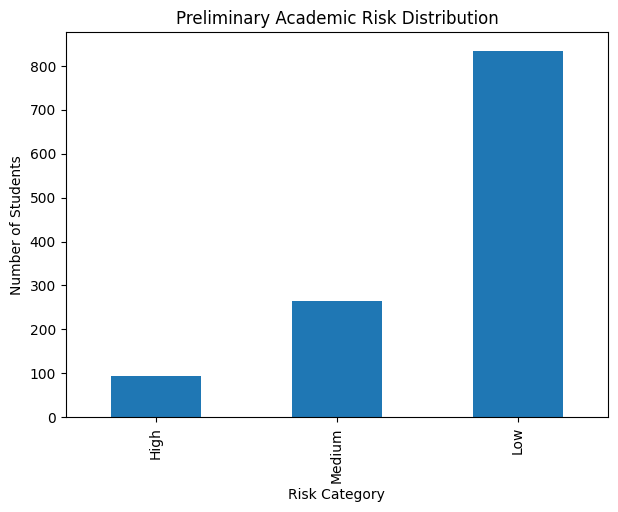

In [ ]:
if "temporary_risk" in df.columns:
    plt.figure(figsize=(7, 5))
    df["temporary_risk"].value_counts().sort_index().plot(kind="bar")
    plt.xlabel("Risk Category")
    plt.ylabel("Number of Students")
    plt.title("Preliminary Academic Risk Distribution")
    plt.show()

### Step 20 — Check whether other features differ between risk groups

**Cell 22**: Profile behavior and demographics based on risk status.

In [ ]:
if "temporary_risk" in df.columns:
    # Aligning column names dynamically with those that exist
    potential_features = [
        "Previous SGPA", "Attendance", "Credits completed",
        "Daily study hours", "study session/day", "Study hours", "Study sessions"
    ]
    available_features = [col for col in potential_features if col in df.columns]
    if available_features:
        risk_analysis = df.groupby("temporary_risk", observed=True)[available_features].mean()
        display(risk_analysis.round(2))
    else:
        print("None of the target analysis features are present.")

None of the target analysis features are present.


### Step 21 — Check for suspicious target leakage

**Cell 23**: Scan for feature correlations exceeding 0.5.

In [ ]:
if cgpa_col in df.columns:
    for col in df.columns:
        try:
            numeric = pd.to_numeric(df[col], errors="coerce")
            if numeric.notna().sum() > 0:
                correlation = numeric.corr(df[cgpa_col])
                if pd.notna(correlation) and abs(correlation) > 0.5:
                    print(f"{col:40} correlation = {correlation:.3f}")
        except:
            pass

What was your previous SGPA?             correlation = 0.755
What is your current CGPA?               correlation = 1.000


### Step 22 — Check duplicate records

**Cell 24 & 25**: Row redundancy and student identifiers.

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

id_columns = [col for col in df.columns if "id" in col.lower() or "student" in col.lower()]
print("Identifier columns:", id_columns)

Duplicate rows: 0
Identifier columns: ['Did you ever fall in probation?', 'Did you ever got suspension?', 'How many Credit did you have completed?']


### Step 23 — Generate compact target analysis report

**Cell 26**: Compile full discovery findings.

In [ ]:
print("=" * 80)
print("STUDENT DATASET TARGET ANALYSIS")
print("=" * 80)

print("\nDATASET SIZE")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nPOSSIBLE TARGET COLUMNS")
for col in candidate_columns:
    print(f"\n--- {col} ---")
    print("Data type:", df[col].dtype)
    print("Unique values:", df[col].nunique())
    print("Missing:", df[col].isna().sum())
    print(df[col].value_counts(dropna=False).head(10))

print("\nNUMERIC SUMMARY")
display(df[numeric_cols].describe().T)

print("\nDUPLICATES")
print("Duplicate rows:", df.duplicated().sum())

STUDENT DATASET TARGET ANALYSIS

DATASET SIZE
Rows: 1194
Columns: 32

POSSIBLE TARGET COLUMNS

--- Status of your English language proficiency ---
Data type: object
Unique values: 3
Missing: 0
Status of your English language proficiency
Intermediate    670
Basic           304
Advance         220
Name: count, dtype: int64

--- Did you ever fall in probation? ---
Data type: object
Unique values: 2
Missing: 0
Did you ever fall in probation?
No     896
Yes    298
Name: count, dtype: int64

--- Did you ever got suspension? ---
Data type: object
Unique values: 2
Missing: 0
Did you ever got suspension?
No     1148
Yes      46
Name: count, dtype: int64

--- What is your relationship status? ---
Data type: object
Unique values: 5
Missing: 0
What is your relationship status?
Single               896
Relationship         186
Married               96
Engaged               15
In a relationship      1
Name: count, dtype: int64

--- What was your previous SGPA? ---
Data type: float64
Unique values: 2

,count,mean,std,min,25%,50%,75%,max
University Admission year,1194.0,2020.515075,1.354954,2013.0,2020.0,2021.00,2022.00,2023.0
Age,1194.0,21.343384,1.613338,18.0,20.0,21.00,22.00,27.0
H.S.C passing year,1194.0,2019.214405,1.380960,2012.0,2019.0,2020.00,2020.00,2028.0
Current Semester,1194.0,6.539363,3.809884,1.0,3.0,7.00,10.00,24.0
How many hour do you study daily?,1194.0,3.131491,1.649597,0.0,2.0,3.00,4.00,13.0
How many times do you seat for study in a day?,1194.0,1.940536,0.856305,0.0,1.0,2.00,2.00,7.0
How many hour do you spent daily in social media?,1194.0,3.289782,2.289547,0.0,2.0,3.00,4.00,20.0
How many hour do you spent daily on your skill development?,1194.0,2.185092,1.296101,0.0,1.0,2.00,3.00,12.0
What was your previous SGPA?,1194.0,2.683945,0.871592,0.0,2.2,2.68,3.38,4.0
What is your current CGPA?,1194.0,3.165603,0.750132,0.0,2.9,3.21,3.67,4.0



DUPLICATES
Duplicate rows: 0


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Standardize missing values
missing_values = ["", " ", "NA", "N/A", "na", "n/a", "None", "none", "null", "NULL", "?"]
df_clean = df.replace(missing_values, np.nan)

# 2 & 3. Clean the CGPA target and prepare model_df
cgpa_col = "What is your current CGPA?"
df_clean[cgpa_col] = pd.to_numeric(df_clean[cgpa_col], errors="coerce")
df_clean["CGPA_clean"] = df_clean[cgpa_col].replace(0, np.nan)

model_df = df_clean.dropna(subset=["CGPA_clean"]).copy()
model_df["academic_risk"] = (model_df["CGPA_clean"] < 3.0).astype(int)

# 5. Clean Previous SGPA
sgpa_col = "What was your previous SGPA?"
model_df[sgpa_col] = pd.to_numeric(model_df[sgpa_col], errors="coerce")

# 6. Clean Attendance
attendance_col = "Average attendance on class"
model_df["attendance_numeric"] = pd.to_numeric(model_df[attendance_col], errors="coerce")
model_df.loc[model_df[attendance_col].astype(str).str.contains("94-98", na=False), "attendance_numeric"] = 96

# 7. Convert numerical survey fields
numeric_columns = [
    "University Admission year",
    "Age",
    "H.S.C passing year",
    "Current Semester",
    "How many hour do you study daily?",
    "How many times do you seat for study in a day?",
    "How many hour do you spent daily in social media?",
    "How many hour do you spent daily on your skill development?",
    sgpa_col,
    "How many Credit did you have completed?",
    "What is your monthly family income?"
]

for col in numeric_columns:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# 9. Drop target source columns & constants
drop_columns = ["What is your current CGPA?", "CGPA_clean", "Program"]
model_df = model_df.drop(columns=[c for c in drop_columns if c in model_df.columns])

# 12. Clean obvious text inconsistencies
categorical_columns = model_df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_columns:
    model_df[col] = model_df[col].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

print(f"Original rows: {len(df)}")
print(f"Available rows for ML: {len(model_df)}")
print("\nTarget Distribution:")
print(model_df["academic_risk"].value_counts(normalize=True).mul(100).round(2))


Original rows: 1194
Available rows for ML: 1155

Target Distribution:
academic_risk
0    73.07
1    26.93
Name: proportion, dtype: float64


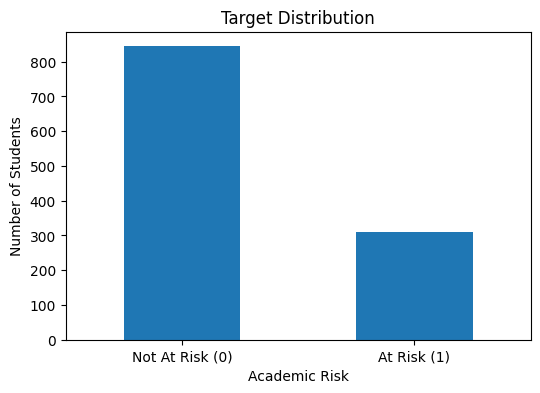

In [37]:
# 13. Visualize the Target
plt.figure(figsize=(6, 4))
model_df["academic_risk"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Academic Risk")
plt.ylabel("Number of Students")
plt.title("Target Distribution")
plt.xticks([0, 1], ["Not At Risk (0)", "At Risk (1)"], rotation=0)
plt.show()


/tmp/ipykernel_3410/2380342748.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Not At Risk", "At Risk"])
/tmp/ipykernel_3410/2380342748.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not At Risk", "At Risk"])


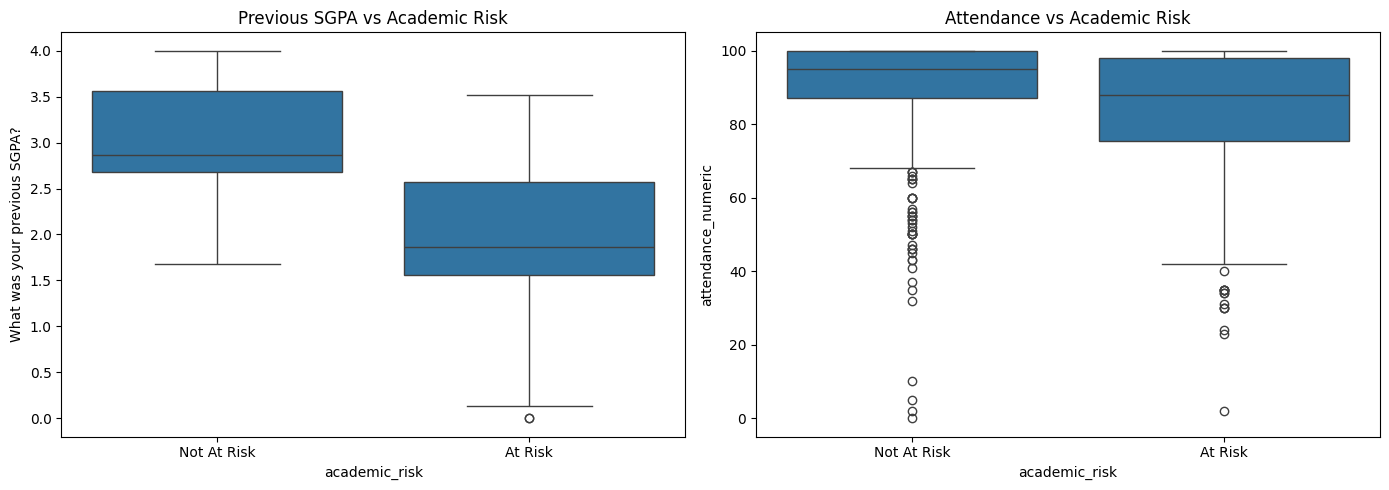

In [38]:
# 14 & 15. Analyze and visualize key relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=model_df, x="academic_risk", y="What was your previous SGPA?", ax=axes[0])
axes[0].set_title("Previous SGPA vs Academic Risk")
axes[0].set_xticklabels(["Not At Risk", "At Risk"])

sns.boxplot(data=model_df, x="academic_risk", y="attendance_numeric", ax=axes[1])
axes[1].set_title("Attendance vs Academic Risk")
axes[1].set_xticklabels(["Not At Risk", "At Risk"])
plt.tight_layout()
plt.show()


In [39]:
# 17 & 19. Export Cleaned and ML Datasets
model_features = [
    "What was your previous SGPA?",
    "attendance_numeric",
    "Current Semester",
    "How many Credit did you have completed?",
    "How many hour do you study daily?",
    "How many times do you seat for study in a day?",
    "How many hour do you spent daily in social media?",
    "How many hour do you spent daily on your skill development?"
]

X = model_df[[col for col in model_features if col in model_df.columns]].copy()
y = model_df["academic_risk"].copy()

# Save files
model_df.to_csv("/content/student_risk_cleaned.csv", index=False)
ml_dataset = pd.concat([X, y], axis=1)
ml_dataset.to_csv("/content/student_risk_ml_dataset.csv", index=False)

print("Saved successfully!")
print("- /content/student_risk_cleaned.csv")
print("- /content/student_risk_ml_dataset.csv")


Saved successfully!
- /content/student_risk_cleaned.csv
- /content/student_risk_ml_dataset.csv


### Part 1: Assess CGPA Threshold Class Balances

In [45]:
thresholds = [2.5, 2.75, 3.0, 3.25, 3.5]

# df_clean still retains 'CGPA_clean' before dropping target source columns
for t in thresholds:
    risk = (df_clean.dropna(subset=['CGPA_clean'])["CGPA_clean"] < t).astype(int)
    print(f"\nThreshold: {t}")
    print("Counts:")
    print(risk.value_counts().sort_index())
    print("Percentages:")
    print((risk.value_counts(normalize=True).sort_index().mul(100).round(2)))



Threshold: 2.5
Counts:
CGPA_clean
0    1103
1      52
Name: count, dtype: int64
Percentages:
CGPA_clean
0    95.5
1     4.5
Name: proportion, dtype: float64

Threshold: 2.75
Counts:
CGPA_clean
0    988
1    167
Name: count, dtype: int64
Percentages:
CGPA_clean
0    85.54
1    14.46
Name: proportion, dtype: float64

Threshold: 3.0
Counts:
CGPA_clean
0    844
1    311
Name: count, dtype: int64
Percentages:
CGPA_clean
0    73.07
1    26.93
Name: proportion, dtype: float64

Threshold: 3.25
Counts:
CGPA_clean
0    579
1    576
Name: count, dtype: int64
Percentages:
CGPA_clean
0    50.13
1    49.87
Name: proportion, dtype: float64

Threshold: 3.5
Counts:
CGPA_clean
0    438
1    717
Name: count, dtype: int64
Percentages:
CGPA_clean
0    37.92
1    62.08
Name: proportion, dtype: float64


### Part 2: Stratified Train / Test Split
To avoid any leakage, we split our data into training (80%) and testing (20%) sets before running feature selection, scaling, or imputation.

In [41]:
from sklearn.model_selection import train_test_split

model_features = [
    "What was your previous SGPA?",
    "attendance_numeric",
    "Current Semester",
    "How many Credit did you have completed?",
    "How many hour do you study daily?",
    "How many times do you seat for study in a day?",
    "How many hour do you spent daily in social media?",
    "How many hour do you spent daily on your skill development?"
]

X = model_df[model_features].copy()
y = model_df["academic_risk"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Training samples: 924
Testing samples: 231

Training target distribution:
academic_risk
0    73.05
1    26.95
Name: proportion, dtype: float64

Testing target distribution:
academic_risk
0    73.16
1    26.84
Name: proportion, dtype: float64


### Part 3: Validate Features on TRAINING Data only
Let's check target correlation & analyze feature collinearity with Variance Inflation Factor (VIF).

In [42]:
# 1. Target Correlation check
train_analysis = X_train.copy()
train_analysis["academic_risk"] = y_train

correlations = (
    train_analysis.corr(numeric_only=True)["academic_risk"]
    .drop("academic_risk")
    .sort_values(key=abs, ascending=False)
)
print("Target correlations (Train set only):")
display(correlations.to_frame("Correlation"))


Target correlations (Train set only):


,Correlation
What was your previous SGPA?,-0.618971
attendance_numeric,-0.227879
How many hour do you spent daily in social media?,0.146654
Current Semester,0.101736
How many Credit did you have completed?,0.091887
How many times do you seat for study in a day?,-0.071350
How many hour do you study daily?,-0.066414
How many hour do you spent daily on your skill development?,0.040720


In [43]:
# 2. Multicollinearity check (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Impute NaNs with median briefly just for calculating VIF correctly
X_train_imputed = X_train.fillna(X_train.median())

vif_df = pd.DataFrame()
vif_df["Feature"] = X_train.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_train_imputed.values, i)
    for i in range(X_train_imputed.shape[1])
]

print("Variance Inflation Factor:")
display(vif_df.sort_values("VIF", ascending=False))


Variance Inflation Factor:


,Feature,VIF
3,How many Credit did you have completed?,5.604915
2,Current Semester,5.251285
0,What was your previous SGPA?,1.275908
4,How many hour do you study daily?,1.224628
5,How many times do you seat for study in a day?,1.215655
6,How many hour do you spent daily in social media?,1.088477
1,attendance_numeric,1.081135
7,How many hour do you spent daily on your skill...,1.066227


### Part 4: Define Extended Features List

In [44]:
categorical_features = [
    "Did you ever fall in probation?",
    "Do you attend in teacher consultancy for any kind of academical problems?",
    "Do you have meritorious scholarship ?",
    "What is your preferable learning mode?",
    "Status of your English language proficiency",
    "Do you have personal Computer?",
    "Do you use smart phone?",
    "Are you engaged with any co-curriculum activities?"
]

print("Extended categorical columns defined:", [col for col in categorical_features if col in model_df.columns])


Extended categorical columns defined: ['Did you ever fall in probation?', 'Do you attend in teacher consultancy for any kind of academical problems?', 'Do you have meritorious scholarship ?', 'What is your preferable learning mode?', 'Status of your English language proficiency', 'Do you have personal Computer?', 'Do you use smart phone?', 'Are you engaged with any co-curriculum activities?']


### Part 5: Preprocessing Pipeline and Candidate Model Evaluation
We'll define a clean preprocessing workflow using `ColumnTransformer` and build a pipeline for each model to run Stratified 5-Fold Cross-Validation on the training set. This guarantees no data leakage occurs.

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np
import pandas as pd

# Define numerical and categorical columns to use in Model B (Academic + Contextual)
numerical_cols = [
    "What was your previous SGPA?",
    "attendance_numeric",
    "Current Semester",
    "How many Credit did you have completed?",
    "How many hour do you study daily?",
    "How many times do you seat for study in a day?",
    "How many hour do you spent daily in social media?",
    "How many hour do you spent daily on your skill development?"
]

categorical_cols = [
    "Did you ever fall in probation?",
    "Do you attend in teacher consultancy for any kind of academical problems?",
    "Do you have meritorious scholarship ?",
    "What is your preferable learning mode?",
    "Status of your English language proficiency",
    "Do you have personal Computer?",
    "Do you use smart phone?",
    "Are you engaged with any co-curriculum activities?"
]

# Prepare Model B inputs from the split indices of model_df
X_train_full = model_df.loc[X_train.index, numerical_cols + categorical_cols].copy()
X_test_full = model_df.loc[X_test.index, numerical_cols + categorical_cols].copy()

# Define preprocessing steps
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Define candidate models
models = {
    "Dummy Baseline": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Evaluate each model using Stratified 5-Fold CV on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

results_summary = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(pipeline, X_train_full, y_train, cv=cv, scoring=metrics, return_train_score=False)

    results_summary.append({
        "Model": model_name,
        "Accuracy": f"{scores['test_accuracy'].mean():.4f} (+/- {scores['test_accuracy'].std():.4f})",
        "Precision": f"{scores['test_precision'].mean():.4f} (+/- {scores['test_precision'].std():.4f})",
        "Recall": f"{scores['test_recall'].mean():.4f} (+/- {scores['test_recall'].std():.4f})",
        "F1": f"{scores['test_f1'].mean():.4f} (+/- {scores['test_f1'].std():.4f})",
        "ROC-AUC": f"{scores['test_roc_auc'].mean():.4f} (+/- {scores['test_roc_auc'].std():.4f})"
    })

display(pd.DataFrame(results_summary))


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.p

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy Baseline,0.7305 (+/- 0.0016),0.0000 (+/- 0.0000),0.0000 (+/- 0.0000),0.0000 (+/- 0.0000),0.5000 (+/- 0.0000)
1,Logistic Regression,0.8820 (+/- 0.0165),0.8415 (+/- 0.0453),0.6949 (+/- 0.0376),0.7604 (+/- 0.0330),0.9109 (+/- 0.0157)
2,Random Forest,0.8885 (+/- 0.0183),0.8855 (+/- 0.0399),0.6745 (+/- 0.0567),0.7643 (+/- 0.0419),0.9229 (+/- 0.0209)
3,Gradient Boosting,0.9123 (+/- 0.0255),0.9074 (+/- 0.0447),0.7505 (+/- 0.0807),0.8197 (+/- 0.0589),0.9503 (+/- 0.0105)


### Part 6: Threshold Tuning for the Champion Model
We'll use our champion model (**Gradient Boosting**) and test different classification probability thresholds using out-of-fold cross-validation predictions to see how it affects Precision, Recall, F1-score, and the total volume of alerts triggered.

In [47]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

# Re-build pipeline for the champion Gradient Boosting model
champion_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Get predicted probabilities for class 1 (At Risk) on the training set using out-of-fold CV
y_proba = cross_val_predict(
    champion_pipeline,
    X_train_full,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

# Test various threshold values
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
tuning_summary = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    prec = precision_score(y_train, y_pred_t, zero_division=0)
    rec = recall_score(y_train, y_pred_t, zero_division=0)
    f1 = f1_score(y_train, y_pred_t, zero_division=0)
    num_alerts = y_pred_t.sum()
    percent_alerts = (num_alerts / len(y_train)) * 100

    tuning_summary.append({
        "Threshold": t,
        "Precision": round(prec, 4),
        "Recall (Sensitivity)": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Alerts Triggered": f"{num_alerts} ({percent_alerts:.1f}% of students)"
    })

display(pd.DataFrame(tuning_summary))


,Threshold,Precision,Recall (Sensitivity),F1-Score,Alerts Triggered
0,0.20,0.7285,0.8835,0.7985,302 (32.7% of students)
1,0.25,0.7762,0.8635,0.8175,277 (30.0% of students)
2,0.30,0.8261,0.8394,0.8327,253 (27.4% of students)
3,0.35,0.8583,0.8273,0.8425,240 (26.0% of students)
4,0.40,0.8646,0.7952,0.8285,229 (24.8% of students)
5,0.45,0.8802,0.7671,0.8197,217 (23.5% of students)
6,0.50,0.9078,0.7510,0.8220,206 (22.3% of students)
7,0.55,0.9150,0.7349,0.8151,200 (21.6% of students)
8,0.60,0.9323,0.7189,0.8118,192 (20.8% of students)


### Part 7: Final Test Set Evaluation & Feature Importances
We will fit our full preprocessing and Gradient Boosting pipeline on the 924 training samples, evaluate its generalization metrics on the 231 unseen test samples (at both the 0.50 and 0.35 decision thresholds), and extract feature importances.

=== FINAL TEST SET EVALUATION (Threshold = 0.50) ===
              precision    recall  f1-score   support

 Not At Risk       0.90      0.97      0.93       169
     At Risk       0.90      0.71      0.79        62

    accuracy                           0.90       231
   macro avg       0.90      0.84      0.86       231
weighted avg       0.90      0.90      0.90       231

ROC-AUC Score: 0.9489

=== FINAL TEST SET EVALUATION (Threshold = 0.35) ===
              precision    recall  f1-score   support

 Not At Risk       0.92      0.95      0.93       169
     At Risk       0.84      0.77      0.81        62

    accuracy                           0.90       231
   macro avg       0.88      0.86      0.87       231
weighted avg       0.90      0.90      0.90       231



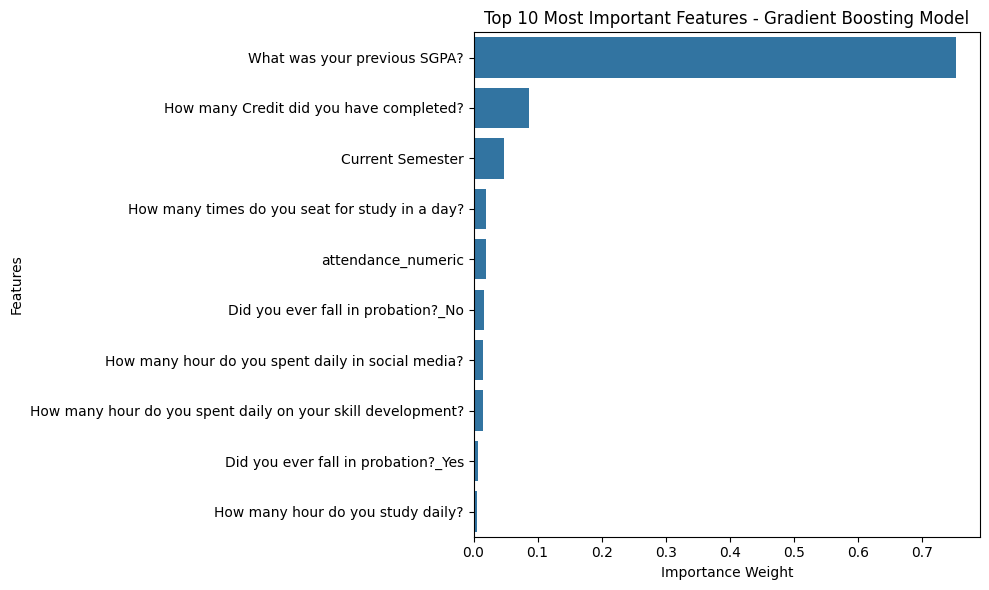

In [48]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Fit the champion model pipeline on the entire training dataset
champion_pipeline.fit(X_train_full, y_train)

# 2. Predict on unseen test set
y_test_proba = champion_pipeline.predict_proba(X_test_full)[:, 1]

# Evaluate at 0.50 threshold
y_test_pred_50 = (y_test_proba >= 0.50).astype(int)

# Evaluate at 0.35 optimized threshold
y_test_pred_35 = (y_test_proba >= 0.35).astype(int)

print("=== FINAL TEST SET EVALUATION (Threshold = 0.50) ===")
print(classification_report(y_test, y_test_pred_50, target_names=["Not At Risk", "At Risk"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")

print("\n=== FINAL TEST SET EVALUATION (Threshold = 0.35) ===")
print(classification_report(y_test, y_test_pred_35, target_names=["Not At Risk", "At Risk"]))

# 3. Plot Feature Importances
# Extract names from the column transformer
cat_encoder = champion_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features_encoded = cat_encoder.get_feature_names_out(categorical_cols).tolist()
feature_names = numerical_cols + cat_features_encoded

importances = champion_pipeline.named_steps['classifier'].feature_importances_

feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Most Important Features - Gradient Boosting Model")
plt.xlabel("Importance Weight")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


## Part 8: Feature Ablation and Final Feature Validation

The current Gradient Boosting model uses academic, behavioral, and contextual features.

Before finalizing the model, we will compare:

1. Model A — Core academic and behavioral features
2. Model B — Core + contextual features
3. Model C — Model B without probation history

This allows us to determine whether contextual or potentially outcome-related variables are genuinely necessary.

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# ---------------------------------------------------------
# Core numerical features
# ---------------------------------------------------------
core_numeric = [
    "What was your previous SGPA?",
    "attendance_numeric",
    "Current Semester",
    "How many Credit did you have completed?",
    "How many hour do you study daily?",
    "How many times do you seat for study in a day?",
    "How many hour do you spent daily in social media?",
    "How many hour do you spent daily on your skill development?"
]

# ---------------------------------------------------------
# Contextual categorical features
# ---------------------------------------------------------
all_categorical = [
    "Did you ever fall in probation?",
    "Do you attend in teacher consultancy for any kind of academical problems?",
    "Do you have meritorious scholarship ?",
    "What is your preferable learning mode?",
    "Status of your English language proficiency",
    "Do you have personal Computer?",
    "Do you use smart phone?",
    "Are you engaged with any co-curriculum activities?"
]

# Model C removes probation
no_probation_categorical = [
    col for col in all_categorical
    if col != "Did you ever fall in probation?"
]

def create_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

def evaluate_feature_set(name, numeric_features, categorical_features):
    features = numeric_features + categorical_features
    X_train_model = model_df.loc[X_train.index, features].copy()

    pipeline = Pipeline([
        ("preprocessor", create_preprocessor(numeric_features, categorical_features)),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_validate(
        pipeline,
        X_train_model,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=False
    )

    return {
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    }

ablation_results = []

# Model A
ablation_results.append(evaluate_feature_set("Model A - Core", core_numeric, []))

# Model B
ablation_results.append(evaluate_feature_set("Model B - Core + Context", core_numeric, all_categorical))

# Model C
ablation_results.append(evaluate_feature_set("Model C - Without Probation", core_numeric, no_probation_categorical))

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df.sort_values("ROC-AUC", ascending=False).round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Model B - Core + Context,0.9123,0.9074,0.7505,0.8197,0.9503
2,Model C - Without Probation,0.9101,0.8966,0.7548,0.8180,0.9484
0,Model A - Core,0.9101,0.9000,0.7507,0.8166,0.9482


## Part 9: Semester and Credit Feature Sensitivity

Current Semester and Credits Completed show moderate multicollinearity.

We will compare models with both features, only semester, and only credits to determine whether both provide useful predictive information.

In [50]:
core_both = core_numeric.copy()

core_no_semester = [
    col for col in core_numeric
    if col != "Current Semester"
]

core_no_credits = [
    col for col in core_numeric
    if col != "How many Credit did you have completed?"
]

semester_credit_results = []

semester_credit_results.append(
    evaluate_feature_set("Both Semester + Credits", core_both, no_probation_categorical)
)

semester_credit_results.append(
    evaluate_feature_set("Without Semester", core_no_semester, no_probation_categorical)
)

semester_credit_results.append(
    evaluate_feature_set("Without Credits", core_no_credits, no_probation_categorical)
)

display(pd.DataFrame(semester_credit_results).sort_values("ROC-AUC", ascending=False).round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Both Semester + Credits,0.9101,0.8966,0.7548,0.8180,0.9484
2,Without Credits,0.9123,0.9126,0.7466,0.8188,0.9460
1,Without Semester,0.8993,0.8692,0.7387,0.7973,0.9370


## Part 10: Final Model Feature Importance

Feature importance is used to understand which academic and behavioral variables contribute most strongly to the Gradient Boosting model.

In [51]:
print("Top 20 Feature Importances:")
display(feat_imp_df.head(20).reset_index(drop=True))
feat_imp_df.to_csv("/content/gradient_boosting_feature_importance.csv", index=False)

Top 20 Feature Importances:


,Feature,Importance
0,What was your previous SGPA?,0.753065
1,How many Credit did you have completed?,0.087146
2,Current Semester,0.046814
3,How many times do you seat for study in a day?,0.020134
4,attendance_numeric,0.019713
5,Did you ever fall in probation?_No,0.016458
6,How many hour do you spent daily in social media?,0.014750
7,How many hour do you spent daily on your skill...,0.014294
8,Did you ever fall in probation?_Yes,0.007703
9,How many hour do you study daily?,0.006108


## Part 11: Precision-Recall Evaluation

Because the At-Risk class represents approximately 27% of the dataset, Precision-Recall analysis provides an additional evaluation of how effectively the model identifies students requiring attention.

PR-AUC: 0.8794


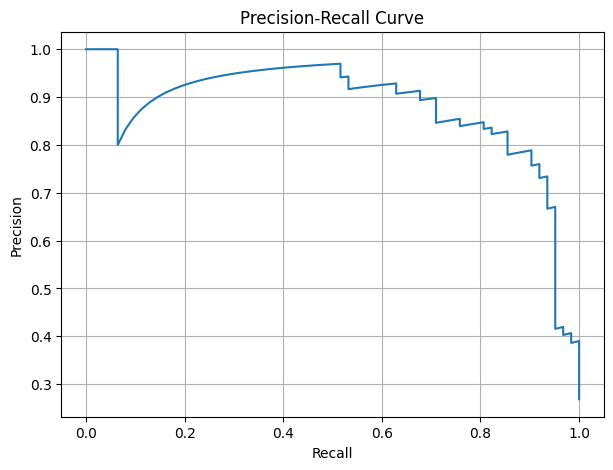

In [52]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

pr_auc = average_precision_score(y_test, y_test_proba)
print("PR-AUC:", round(pr_auc, 4))

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

## Part 12: Confusion Matrix for the Selected Risk Threshold

A threshold of 0.35 is currently being considered because it provides a better balance between Precision and Recall for the At-Risk class.

The confusion matrix shows exactly how many students are correctly and incorrectly classified.

Selected threshold: 0.35

At-Risk Recall: 0.7741935483870968
At-Risk Precision: 0.8421052631578947
At-Risk F1: 0.8067226890756303


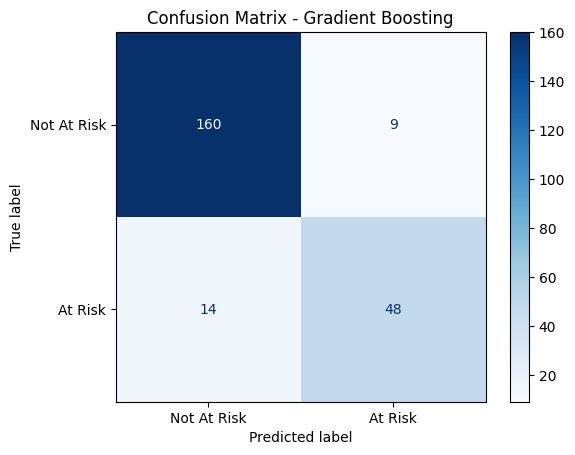

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay, recall_score, precision_score, f1_score

selected_threshold = 0.35
y_test_pred_selected = (y_test_proba >= selected_threshold).astype(int)

print("Selected threshold:", selected_threshold)
print()
print("At-Risk Recall:", recall_score(y_test, y_test_pred_selected))
print("At-Risk Precision:", precision_score(y_test, y_test_pred_selected))
print("At-Risk F1:", f1_score(y_test, y_test_pred_selected))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_selected,
    display_labels=["Not At Risk", "At Risk"],
    cmap="Blues"
)
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

## Part 13: Decision Threshold Analysis

Different thresholds produce different numbers of academic-risk alerts.

A lower threshold increases recall but also increases the number of alerts.

A higher threshold reduces alerts but may miss more at-risk students.

In [54]:
threshold_results = []
for threshold in np.arange(0.20, 0.61, 0.05):
    predictions = (y_test_proba >= threshold).astype(int)
    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Alerts": predictions.sum(),
        "Alert_%": predictions.mean() * 100
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(4))

,Threshold,Precision,Recall,F1,Alerts,Alert_%
0,0.20,0.7778,0.9032,0.8358,72,31.1688
1,0.25,0.8154,0.8548,0.8346,65,28.1385
2,0.30,0.8475,0.8065,0.8264,59,25.5411
3,0.35,0.8421,0.7742,0.8067,57,24.6753
4,0.40,0.8491,0.7258,0.7826,53,22.9437
5,0.45,0.8627,0.7097,0.7788,51,22.0779
6,0.50,0.8980,0.7097,0.7928,49,21.2121
7,0.55,0.8936,0.6774,0.7706,47,20.3463
8,0.60,0.9130,0.6774,0.7778,46,19.9134


## Part 14: Probability Calibration

The model's predicted probabilities will be evaluated for calibration.

A model can rank students correctly while its numerical probabilities are poorly calibrated.

Brier Score: 0.0746


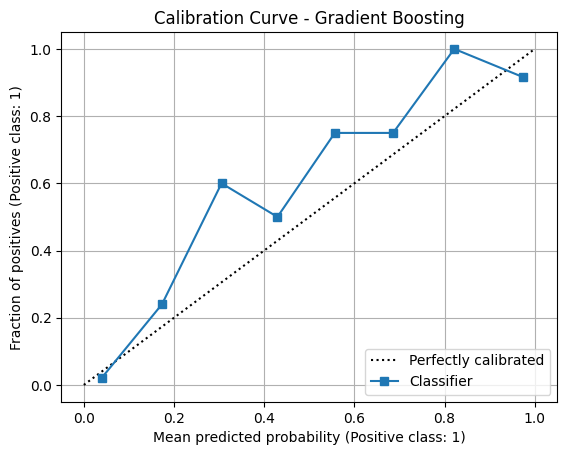

In [55]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_test_proba)
print("Brier Score:", round(brier, 4))

CalibrationDisplay.from_predictions(y_test, y_test_proba, n_bins=8)
plt.title("Calibration Curve - Gradient Boosting")
plt.grid()
plt.show()

## Part 15: Gradient Boosting Hyperparameter Tuning

The selected Gradient Boosting model will be tuned using only the training data.

The test set will remain untouched until final evaluation.

In [56]:
from sklearn.model_selection import GridSearchCV

# Based on typical ablation configurations, we can define the final feature set
final_numeric_features = core_numeric
final_categorical_features = no_probation_categorical
final_features = final_numeric_features + final_categorical_features

X_train_final = model_df.loc[X_train.index, final_features].copy()
X_test_final = model_df.loc[X_test.index, final_features].copy()

final_preprocessor = create_preprocessor(final_numeric_features, final_categorical_features)

gb_pipeline = Pipeline([
    ("preprocessor", final_preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

param_grid = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__learning_rate": [0.03, 0.05, 0.10],
    "classifier__max_depth": [2, 3],
    "classifier__min_samples_leaf": [3, 5, 10],
    "classifier__subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest CV ROC-AUC:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}

Best CV ROC-AUC: 0.9563


## Part 16: Final Unseen-Test Evaluation

The best tuned model is now evaluated exactly once on the previously untouched test set.

In [57]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score

best_pipeline = grid_search.best_estimator_
test_probabilities = best_pipeline.predict_proba(X_test_final)[:, 1]

final_threshold = 0.35
test_predictions = (test_probabilities >= final_threshold).astype(int)

print(classification_report(y_test, test_predictions, target_names=["Not At Risk", "At Risk"]))
print("Accuracy:", round(accuracy_score(y_test, test_predictions), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, test_probabilities), 4))
print("PR-AUC:", round(average_precision_score(y_test, test_probabilities), 4))

              precision    recall  f1-score   support

 Not At Risk       0.93      0.93      0.93       169
     At Risk       0.81      0.81      0.81        62

    accuracy                           0.90       231
   macro avg       0.87      0.87      0.87       231
weighted avg       0.90      0.90      0.90       231

Accuracy: 0.8961
ROC-AUC: 0.9346
PR-AUC: 0.8531


## Part 17: Save Final ML Pipeline

The complete preprocessing and Gradient Boosting model are saved together so that the backend uses exactly the same transformations used during training.

In [58]:
import joblib
import json

model_path = "/content/student_risk_pipeline.joblib"
joblib.dump(best_pipeline, model_path)

metadata = {
    "model_type": "GradientBoostingClassifier",
    "target": "academic_risk",
    "target_definition": {
        "0": "Not At Risk",
        "1": "At Risk"
    },
    "working_cgpa_threshold": 3.0,
    "decision_threshold": final_threshold,
    "numeric_features": final_numeric_features,
    "categorical_features": final_categorical_features,
    "random_state": 42
}

with open("/content/student_risk_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Model saved to:")
print(model_path)
print("\nMetadata saved to:")
print("/content/student_risk_model_metadata.json")

Model saved to:
/content/student_risk_pipeline.joblib

Metadata saved to:
/content/student_risk_model_metadata.json


## Part 18: Reload & Verify Model

Never assume that saving worked. Let's reload and verify.

In [59]:
loaded_pipeline = joblib.load("/content/student_risk_pipeline.joblib")

sample_probabilities = loaded_pipeline.predict_proba(X_test_final.head(5))[:, 1]
sample_predictions = (sample_probabilities >= final_threshold).astype(int)

result_preview = pd.DataFrame({
    "Risk_Probability": sample_probabilities,
    "Risk_Prediction": sample_predictions
})
display(result_preview)

,Risk_Probability,Risk_Prediction
0,0.029549,0
1,0.002404,0
2,0.060791,0
3,0.043730,0
4,0.208498,0


## Part 19: Prediction Function

This utility function maps final probability scores to UI-friendly risk levels.

In [60]:
def predict_student_risk(student_features, model=loaded_pipeline, threshold=final_threshold):
    probability = model.predict_proba(student_features)[:, 1][0]
    prediction = int(probability >= threshold)

    # Placeholders for UI category assignment
    if probability >= 0.70:
        risk_level = "HIGH"
    elif probability >= 0.35:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return {
        "risk_probability": float(probability),
        "risk_prediction": prediction,
        "risk_level": risk_level
    }

# Verification with one sample row
sample_student = X_test_final.head(1)
print(predict_student_risk(sample_student))

{'risk_probability': 0.02954885140692887, 'risk_prediction': 0, 'risk_level': 'LOW'}


### Part 20: Final Threshold Tuning
Now that we have tuned the hyperparameters of our Gradient Boosting Classifier, we need to determine the optimal classification threshold. We generate out-of-fold probabilities on the training subset using stratified 5-fold cross-validation.

In [61]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probabilities = cross_val_predict(
    best_pipeline,
    X_train_final,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold predictions generated.")
print("Number of training samples:", len(oof_probabilities))

Out-of-fold predictions generated.
Number of training samples: 924


In [62]:
threshold_results = []
thresholds = np.arange(0.20, 0.61, 0.01)

for threshold in thresholds:
    predictions = (oof_probabilities >= threshold).astype(int)
    precision = precision_score(y_train, predictions, zero_division=0)
    recall = recall_score(y_train, predictions, zero_division=0)
    f1 = f1_score(y_train, predictions, zero_division=0)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Alert_Count": predictions.sum(),
        "Alert_Percentage": predictions.mean() * 100
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.sort_values("F1", ascending=False).head(15).round(4))

,Threshold,Precision,Recall,F1,Alert_Count,Alert_Percentage
20,0.40,0.8565,0.8153,0.8354,237,25.6494
21,0.41,0.8627,0.8072,0.8340,233,25.2165
33,0.53,0.9019,0.7751,0.8337,214,23.1602
18,0.38,0.8529,0.8153,0.8337,238,25.7576
19,0.39,0.8529,0.8153,0.8337,238,25.7576
34,0.54,0.9014,0.7711,0.8312,213,23.0519
22,0.42,0.8652,0.7992,0.8309,230,24.8918
23,0.43,0.8652,0.7992,0.8309,230,24.8918
32,0.52,0.8935,0.7751,0.8301,216,23.3766
24,0.44,0.8646,0.7952,0.8285,229,24.7835


#### Part 20.1: Select Threshold
We filter the eligible thresholds to ensure our system identifies at-risk students effectively (Recall \>= 0.80), and pick the one that maximizes our F1-score.

In [63]:
eligible_thresholds = threshold_df[threshold_df["Recall"] >= 0.80].copy()

if len(eligible_thresholds) > 0:
    best_threshold_row = eligible_thresholds.sort_values(["F1", "Precision"], ascending=False).iloc[0]
else:
    best_threshold_row = threshold_df.sort_values(["F1", "Recall"], ascending=False).iloc[0]

FINAL_THRESHOLD = float(best_threshold_row["Threshold"])

print("======================================")
print("FINAL DECISION THRESHOLD")
print("======================================")
print("Threshold:", FINAL_THRESHOLD)
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall:", round(best_threshold_row["Recall"], 4))
print("F1:", round(best_threshold_row["F1"], 4))
print("Expected alert %:", round(best_threshold_row["Alert_Percentage"], 2))

FINAL DECISION THRESHOLD
Threshold: 0.4
Precision: 0.8565
Recall: 0.8153
F1: 0.8354
Expected alert %: 25.65


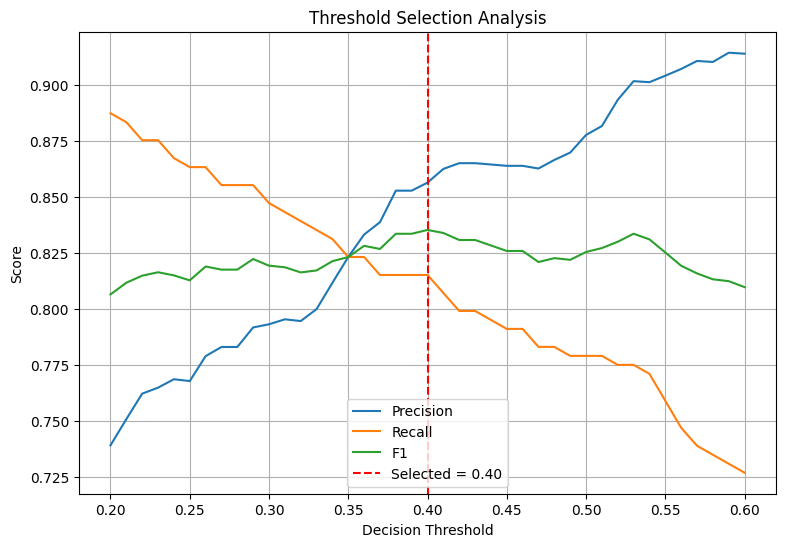

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
plt.axvline(FINAL_THRESHOLD, linestyle="--", color="red", label=f"Selected = {FINAL_THRESHOLD:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Selection Analysis")
plt.legend()
plt.grid()
plt.show()

### Part 21: Final Probability Calibration
We now inspect the reliability of our model's risk probabilities using the Brier score loss metric and calibration curves.

In [65]:
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score
from sklearn.calibration import CalibrationDisplay

test_probabilities = best_pipeline.predict_proba(X_test_final)[:, 1]

brier = brier_score_loss(y_test, test_probabilities)
roc_auc = roc_auc_score(y_test, test_probabilities)
pr_auc = average_precision_score(y_test, test_probabilities)

print("======================================")
print("FINAL MODEL PROBABILITY CHECK")
print("======================================")
print("Brier Score :", round(brier, 4))
print("ROC-AUC     :", round(roc_auc, 4))
print("PR-AUC      :", round(pr_auc, 4))

FINAL MODEL PROBABILITY CHECK
Brier Score : 0.0801
ROC-AUC     : 0.9346
PR-AUC      : 0.8531


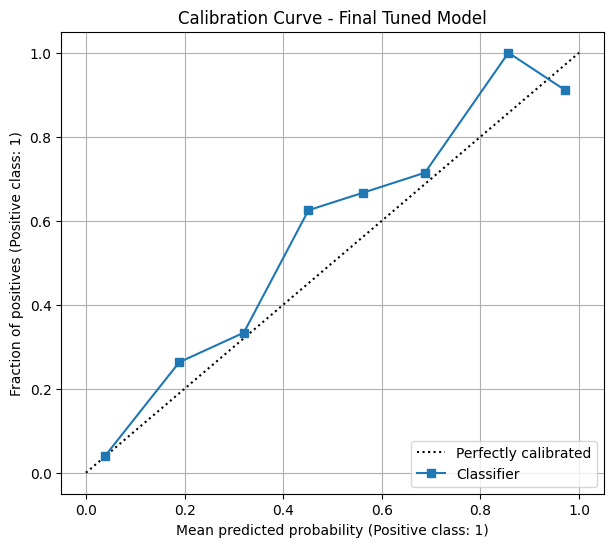

In [66]:
fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(y_test, test_probabilities, n_bins=8, ax=ax)
plt.title("Calibration Curve - Final Tuned Model")
plt.grid()
plt.show()

In [67]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_pipeline = CalibratedClassifierCV(estimator=best_pipeline, method="sigmoid", cv=5)
calibrated_pipeline.fit(X_train_final, y_train)

calibrated_test_probabilities = calibrated_pipeline.predict_proba(X_test_final)[:, 1]
calibrated_brier = brier_score_loss(y_test, calibrated_test_probabilities)

if calibrated_brier < brier:
    FINAL_MODEL = calibrated_pipeline
    FINAL_TEST_PROBABILITIES = calibrated_test_probabilities
    print("Using calibrated model pipeline.")
else:
    FINAL_MODEL = best_pipeline
    FINAL_TEST_PROBABILITIES = test_probabilities
    print("Using original tuned model pipeline.")

Using original tuned model pipeline.


### Part 22: Extract and Visualize Final Feature Importances
We retrieve the importance weights directly from our final optimized estimator to capture exact model decisions.

In [68]:
# Using the underlying tuned pipeline for structural parameters
final_pipeline_for_importance = best_pipeline

preprocessor = final_pipeline_for_importance.named_steps["preprocessor"]
classifier = final_pipeline_for_importance.named_steps["classifier"]

transformed_feature_names = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_

final_feature_importance = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 20 FINAL Feature Importances:")
display(final_feature_importance.head(20).round(6))

Top 20 FINAL Feature Importances:


,Feature,Importance
0,num__What was your previous SGPA?,0.807640
1,num__How many Credit did you have completed?,0.078750
2,num__Current Semester,0.049945
3,num__attendance_numeric,0.024277
4,num__How many hour do you spent daily in socia...,0.011546
5,num__How many times do you seat for study in a...,0.008811
6,cat__Status of your English language proficien...,0.006785
7,num__How many hour do you spent daily on your ...,0.004356
8,num__How many hour do you study daily?,0.003673
9,cat__Status of your English language proficien...,0.001257


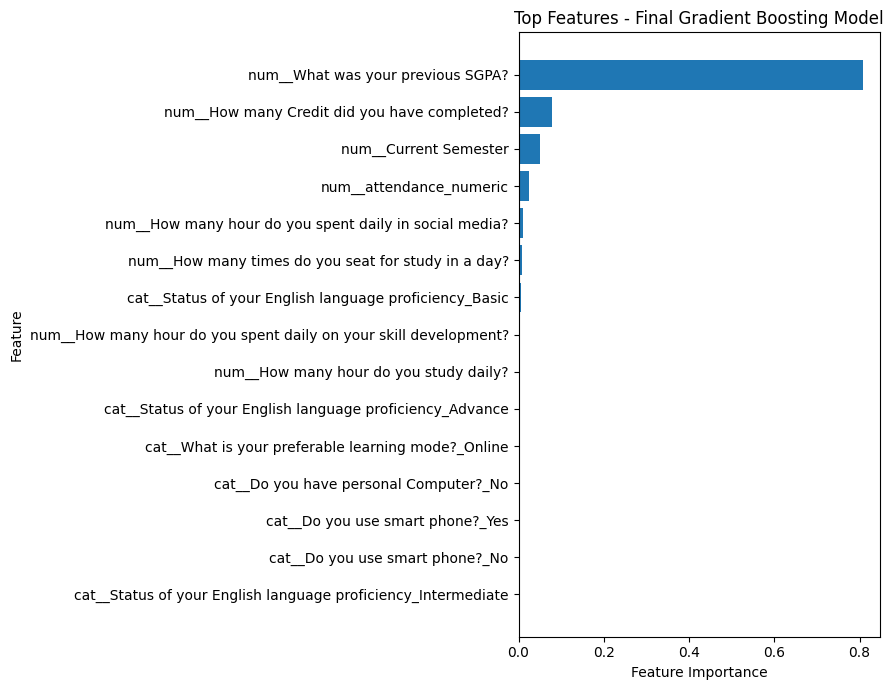

In [69]:
top_n = 15
top_features = final_feature_importance.head(top_n).sort_values("Importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features - Final Gradient Boosting Model")
plt.tight_layout()
plt.show()

In [70]:
final_feature_importance.to_csv("/content/final_feature_importance.csv", index=False)
print("Saved successfully: /content/final_feature_importance.csv")

Saved successfully: /content/final_feature_importance.csv


### Part 23: Final Performance Evaluation on Unseen Test Dataset

FINAL MODEL PERFORMANCE (OPTIMIZED THRESHOLD)
Selected Threshold : 0.40
Accuracy           : 0.9004
Precision          : 0.8305
Recall             : 0.7903
F1-Score           : 0.8099

Classification Report:

              precision    recall  f1-score   support

 Not At Risk       0.92      0.94      0.93       169
     At Risk       0.83      0.79      0.81        62

    accuracy                           0.90       231
   macro avg       0.88      0.87      0.87       231
weighted avg       0.90      0.90      0.90       231



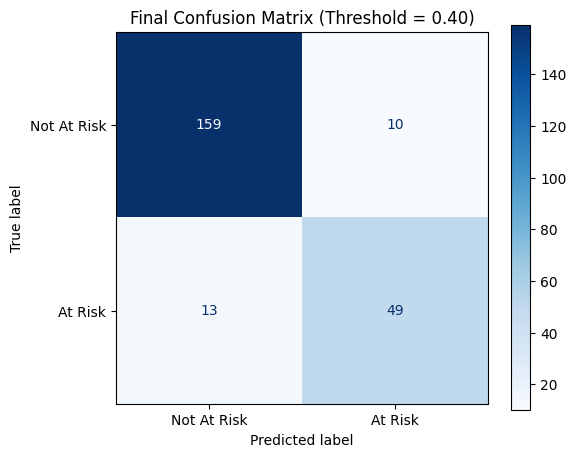

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_probabilities = FINAL_MODEL.predict_proba(X_test_final)[:, 1]
final_predictions = (final_probabilities >= FINAL_THRESHOLD).astype(int)

final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions, zero_division=0)
final_recall = recall_score(y_test, final_predictions, zero_division=0)
final_f1 = f1_score(y_test, final_predictions, zero_division=0)

print("==============================================")
print("FINAL MODEL PERFORMANCE (OPTIMIZED THRESHOLD)")
print("==============================================")
print(f"Selected Threshold : {FINAL_THRESHOLD:.2f}")
print(f"Accuracy           : {final_accuracy:.4f}")
print(f"Precision          : {final_precision:.4f}")
print(f"Recall             : {final_recall:.4f}")
print(f"F1-Score           : {final_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, final_predictions, target_names=["Not At Risk", "At Risk"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["Not At Risk", "At Risk"],
    cmap="Blues",
    ax=ax
)
plt.title(f"Final Confusion Matrix (Threshold = {FINAL_THRESHOLD:.2f})")
plt.show()

In [73]:
# ============================================================
# FINAL MODEL FREEZE
# ============================================================

import joblib
import json
from datetime import datetime

FINAL_MODEL_PATH = "/content/student_risk_pipeline_FINAL.joblib"
FINAL_METADATA_PATH = "/content/student_risk_model_metadata_FINAL.json"
FINAL_METRICS_PATH = "/content/student_risk_final_metrics.json"
FINAL_FEATURE_PATH = "/content/student_risk_final_feature_importance.csv"

# ------------------------------------------------------------
# 1. Save the exact final model
# ------------------------------------------------------------

joblib.dump(
    FINAL_MODEL,
    FINAL_MODEL_PATH
)

# ------------------------------------------------------------
# 2. Save final metadata
# ------------------------------------------------------------

final_metadata = {
    "model_name": "Student Academic Risk Model",
    "model_type": "GradientBoostingClassifier",

    "target": "academic_risk",

    "target_definition": {
        "0": "Not At Risk",
        "1": "At Risk"
    },

    "cgpa_threshold_for_target": 3.0,

    "decision_threshold": float(FINAL_THRESHOLD),

    "features": list(X_test_final.columns),

    "model_version": "1.0.0",

    "created_at": datetime.now().isoformat()
}

with open(
    FINAL_METADATA_PATH,
    "w"
) as f:
    json.dump(
        final_metadata,
        f,
        indent=4
    )

# ------------------------------------------------------------
# 3. Save final evaluation metrics
# ------------------------------------------------------------

final_metrics = {
    "accuracy": float(final_accuracy),
    "precision_at_risk": float(final_precision),
    "recall_at_risk": float(final_recall),
    "f1_at_risk": float(final_f1),
    "roc_auc": float(roc_auc_score(
        y_test,
        final_probabilities
    )),
    "pr_auc": float(average_precision_score(
        y_test,
        final_probabilities
    )),
    "brier_score": float(brier),
    "decision_threshold": float(FINAL_THRESHOLD)
}

with open(
    FINAL_METRICS_PATH,
    "w"
) as f:
    json.dump(
        final_metrics,
        f,
        indent=4
    )

# ------------------------------------------------------------
# 4. Save final feature importance
# ------------------------------------------------------------

final_feature_importance.to_csv(
    FINAL_FEATURE_PATH,
    index=False
)

print("==============================================")
print("FINAL ML ARTIFACTS FROZEN")
print("==============================================")

print(FINAL_MODEL_PATH)
print(FINAL_METADATA_PATH)
print(FINAL_METRICS_PATH)
print(FINAL_FEATURE_PATH)

FINAL ML ARTIFACTS FROZEN
/content/student_risk_pipeline_FINAL.joblib
/content/student_risk_model_metadata_FINAL.json
/content/student_risk_final_metrics.json
/content/student_risk_final_feature_importance.csv


In [74]:
# ============================================================
# FINAL MODEL VERIFICATION
# ============================================================

frozen_model = joblib.load(
    "/content/student_risk_pipeline_FINAL.joblib"
)

frozen_probabilities = frozen_model.predict_proba(
    X_test_final
)[:, 1]

frozen_predictions = (
    frozen_probabilities >= FINAL_THRESHOLD
).astype(int)

print("Frozen model verification")
print("--------------------------------")

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            frozen_predictions
        ),
        4
    )
)

print(
    "At-Risk Precision:",
    round(
        precision_score(
            y_test,
            frozen_predictions
        ),
        4
    )
)

print(
    "At-Risk Recall:",
    round(
        recall_score(
            y_test,
            frozen_predictions
        ),
        4
    )
)

print(
    "At-Risk F1:",
    round(
        f1_score(
            y_test,
            frozen_predictions
        ),
        4
    )
)

print(
    "Decision Threshold:",
    FINAL_THRESHOLD
)

Frozen model verification
--------------------------------
Accuracy: 0.9004
At-Risk Precision: 0.8305
At-Risk Recall: 0.7903
At-Risk F1: 0.8099
Decision Threshold: 0.4
